# 🏆 10. Grayscale Average (AVG) Testing SVM (Loaded from Single .keras Container)

Notebook ini mengevaluasi kinerja SVM Classifier pada fitur testing CIFAR-10.
StandardScaler dan Model SVM dimuat **langsung dari file model tunggal .keras** (custom_cnn_cifar10_final.keras) via dataset HDF5 (/scaler_pickle & /svm_model_pickle) tanpa perlu training ulang.


In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import json
import h5py
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
final_keras_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')

def load_injected_final_model(artifact_path):
    if not os.path.exists(artifact_path):
        raise FileNotFoundError(f"File model {artifact_path} tidak ditemukan!")
    cnn_model = tf.keras.models.load_model(artifact_path)
    with h5py.File(artifact_path, 'r') as h5f:
        if 'scaler_pickle' in h5f and 'svm_model_pickle' in h5f:
            scaler_bytes = bytes(h5f['scaler_pickle'][()])
            svm_bytes = bytes(h5f['svm_model_pickle'][()])
            scaler = pickle.loads(scaler_bytes)
            svm_model = pickle.loads(svm_bytes)
        elif 'svm_pipeline_pickle' in h5f:
            pipe_bytes = bytes(h5f['svm_pipeline_pickle'][()])
            pipe_obj = pickle.loads(pipe_bytes)
            if hasattr(pipe_obj, 'named_steps'):
                scaler = pipe_obj.named_steps.get('scaler', None)
                svm_model = pipe_obj.named_steps.get('svm', pipe_obj)
            else:
                scaler = None
                svm_model = pipe_obj
        else:
            raise KeyError(f"Dataset Scaler/SVM tidak ditemukan dalam {artifact_path}!")
        metadata = {}
        for k, v in h5f.attrs.items():
            if isinstance(v, bytes):
                metadata[k] = v.decode('utf-8')
            else:
                metadata[k] = v
    return cnn_model, scaler, svm_model, metadata


def evaluate_classification(y_true, y_pred, title='Model Evaluation', plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=================================================================')
    print(f'  {title.upper()}')
    print('=================================================================')
    print(f'  Accuracy           : {acc * 100:.2f}% ({acc:.4f})')
    print(f'  Precision (Macro)  : {prec_macro * 100:.2f}% ({prec_macro:.4f})')
    print(f'  Recall (Macro)     : {rec_macro * 100:.2f}% ({rec_macro:.4f})')
    print(f'  F1-Score (Macro)   : {f1_macro * 100:.2f}% ({f1_macro:.4f})')
    print('-----------------------------------------------------------------')
    print(f'  Precision (Weight) : {prec_weighted * 100:.2f}% ({prec_weighted:.4f})')
    print(f'  Recall (Weight)    : {rec_weighted * 100:.2f}% ({rec_weighted:.4f})')
    print(f'  F1-Score (Weight)  : {f1_weighted * 100:.2f}% ({f1_weighted:.4f})')
    print('=================================================================')
    print('\n--- CLASSIFICATION REPORT ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f'Confusion Matrix: {title}', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=200)
            print(f'[INFO] Confusion Matrix heatmap disimpan ke: {save_cm_path}')
        plt.show()

    return {
        'accuracy': float(acc),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(prec_weighted),
        'recall_weighted': float(rec_weighted),
        'f1_weighted': float(f1_weighted),
        'confusion_matrix': cm.tolist()
    }

scaler = None
svm_model = None

# Prioritaskan pemuatan dari file standalone .pkl jika tersedia
scaler_pkl_path = os.path.join(ARTIFACT_DIR, 'scaler.pkl')
svm_pkl_path = os.path.join(ARTIFACT_DIR, 'svm_model.pkl')
if os.path.exists(scaler_pkl_path) and os.path.exists(svm_pkl_path):
    try:
        with open(scaler_pkl_path, 'rb') as f:
            scaler = pickle.load(f)
        with open(svm_pkl_path, 'rb') as f:
            svm_model = pickle.load(f)
        print(f"[BERHASIL] Scaler dan SVM Model dimuat dari file .pkl di {ARTIFACT_DIR}!")
    except Exception as e:
        print(f"[INFO] Gagal memuat dari file .pkl: {e}. Mencoba dari container .keras...")

if svm_model is None:
    print(f"Memuat model dari SATU file .keras: {final_keras_path}")
    cnn_model, scaler, svm_model, metadata = load_injected_final_model(final_keras_path)
    print(f"[BERHASIL] Scaler dan SVM Model berhasil dimuat dari file .keras!")
    print("Metadata:", metadata)


[BERHASIL] Scaler dan SVM Model dimuat dari file .pkl di cifar10_artifacts/grayscale_avg!


## 📥 1. Memuat Vektor Fitur Testing, Transformasi Scaler & Inferensi SVM


In [2]:
test_feat_path = os.path.join(ARTIFACT_DIR, 'test_features.npz')
test_data = np.load(test_feat_path)
X_test_features = test_data['X_test_features']
y_test = test_data['y_test']

print("1. Menstandarisasi vektor fitur testing menggunakan scaler training...")
if scaler is not None:
    X_test_scaled = scaler.transform(X_test_features)
else:
    X_test_scaled = X_test_features
print(f"Bentuk fitur testing terskala: {X_test_scaled.shape}")

print()
print("2. Menjalankan prediksi SVM pada seluruh test set (10.000 sampel)...")
y_pred_svm = svm_model.predict(X_test_scaled)

1. Menstandarisasi vektor fitur testing menggunakan scaler training...
Bentuk fitur testing terskala: (10000, 512)

2. Menjalankan prediksi SVM pada seluruh test set (10.000 sampel)...


## 📊 2. Classification Report & Confusion Matrix (SVM)


  GRAYSCALE AVERAGE (AVG) CNN + SVM EVALUATION
  Accuracy           : 91.53% (0.9153)
  Precision (Macro)  : 91.53% (0.9153)
  Recall (Macro)     : 91.53% (0.9153)
  F1-Score (Macro)   : 91.53% (0.9153)
-----------------------------------------------------------------
  Precision (Weight) : 91.53% (0.9153)
  Recall (Weight)    : 91.53% (0.9153)
  F1-Score (Weight)  : 91.53% (0.9153)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    airplane     0.9246    0.9440    0.9342      1000
  automobile     0.9464    0.9720    0.9591      1000
        bird     0.8794    0.8750    0.8772      1000
         cat     0.8156    0.8270    0.8213      1000
        deer     0.8943    0.8970    0.8957      1000
         dog     0.8842    0.8550    0.8693      1000
        frog     0.9427    0.9380    0.9404      1000
       horse     0.9451    0.9460    0.9455      1000
        ship     0.9588    0.9550    0.9569      1000
       truck     0.9623    0.9440    0.953

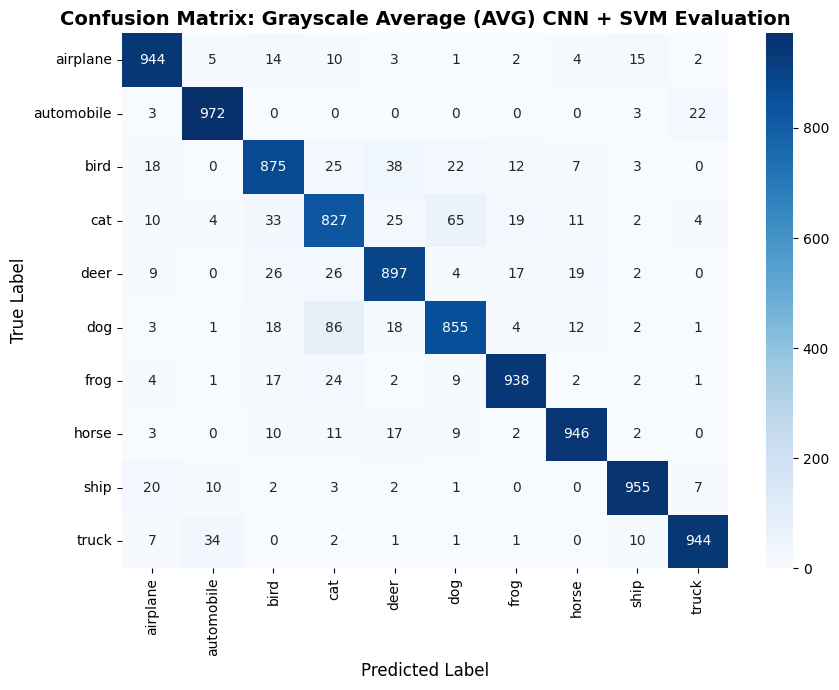


[FINAL RESULT] Grayscale Average (AVG) CNN + SVM Test Accuracy: 91.53%
[FINAL RESULT] Grayscale Average (AVG) CNN + SVM F1-Score (Macro): 91.53%


In [3]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_svm.png')
metrics_svm = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_svm,
    title="Grayscale Average (AVG) CNN + SVM Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

with open(os.path.join(ARTIFACT_DIR, 'metrics_svm.json'), 'w') as f:
    json.dump(metrics_svm, f, indent=2)

# Perbarui juga metrics.json agar selalu sinkron
metrics_json_path = os.path.join(ARTIFACT_DIR, 'metrics.json')
existing_metrics = {}
if os.path.exists(metrics_json_path):
    try:
        with open(metrics_json_path, 'r') as f:
            existing_metrics = json.load(f)
    except Exception:
        pass
existing_metrics['svm_test_accuracy'] = float(metrics_svm['accuracy'])
with open(metrics_json_path, 'w') as f:
    json.dump(existing_metrics, f, indent=2)

print()
print(f"[FINAL RESULT] Grayscale Average (AVG) CNN + SVM Test Accuracy: {metrics_svm['accuracy'] * 100:.2f}%")
print(f"[FINAL RESULT] Grayscale Average (AVG) CNN + SVM F1-Score (Macro): {metrics_svm['f1_macro'] * 100:.2f}%")
